# Tutorial 5: Neural Architecture Search (NAS) with Mase and Optuna

In this tutorial, we'll see how Mase can be integrated with Optuna, the popular hyperparameter optimization framework, to search for a Bert model optimized for sequence classification on the IMDb dataset. We'll take the Optuna-generated model and import it into Mase, then run the CompressionPipeline to prepare the model for edge deployment by quantizing and pruning its weights.

As we'll see, running Architecture Search with Mase/Optuna involves the following steps.

1. **Define the search space**: this is a dictionary containing the range of values for each parameter at each layer in the model.

2. **Write the model constructor**: this is a function which uses Optuna utilities to sample a model from the search space, and constructs the model using transformers from_config class method.

3. **Write the objective function**: this function calls on the model constructor defined in Step 2 and defines the training/evaluation setup for each search iteration.

4. **Go!** Choose an Optuna sampler, create a study and launch the search.

In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

First, fetch the dataset using the `get_tokenized_dataset` utility.

In [2]:
from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


## 1. Defining the Search Space

We'll start by defining a search space, i.e. enumerating the possible combinations of hyperparameters that Optuna can choose during search. We'll explore the following range of values for the model's hidden size, intermediate size, number of layers and number of heads, inspired by the [NAS-BERT paper](https://arxiv.org/abs/2105.14444).

In [3]:
import torch.nn as nn
from chop.nn.modules import Identity

search_space = {
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choices": [
        nn.Linear,
        Identity,
    ],
}

## 2. Writing a Model Constructor

We define the following function, which will get called in each iteration of the search process. The function is passed the `trial` argument, which is an Optuna object that comes with many functionalities - see the [Trial documentation](https://optuna.readthedocs.io/en/stable/reference/trial.html) for more details. Here, we use the `trial.suggest_int` and `trial.suggest_categorical` functions to trigger the chosen sampler to choose parameter choices and layer types. The suggested integer is the index into the search space for each parameter, which we defined in the previous cell.

In [5]:
from transformers import AutoConfig, AutoModelForSequenceClassification
from chop.tools.utils import deepsetattr


def construct_model(trial):
    config = AutoConfig.from_pretrained(checkpoint)

    # Update the paramaters in the config
    for param in [
        "num_layers",
        "num_heads",
        "hidden_size",
        "intermediate_size",
    ]:
        chosen_idx = trial.suggest_int(param, 0, len(search_space[param]) - 1)
        setattr(config, param, search_space[param][chosen_idx])

    trial_model = AutoModelForSequenceClassification.from_config(config)

    for name, layer in trial_model.named_modules():
        if isinstance(layer, nn.Linear) and layer.in_features == layer.out_features:
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                search_space["linear_layer_choices"],
            )

            if new_layer_cls == nn.Linear:
                continue
            elif new_layer_cls == Identity:
                new_layer = Identity()
                deepsetattr(trial_model, name, new_layer)
            else:
                raise ValueError(f"Unknown layer type: {new_layer_cls}")

    return trial_model

## 3. Defining the Objective Function

Next, we define the objective function for the search, which gets called on each trial. In each trial, we create a new model instace with chosen hyperparameters according to the defined sampler. We then use the `get_trainer` utility in Mase to run a training loop on the IMDb dataset for a number of epochs. Finally, we use `evaluate` to report back the classification accuracy on the test split.

In [6]:
from chop.tools import get_trainer


def objective(trial):

    # Define the model
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    # Set the model as an attribute so we can fetch it later
    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]

## 4. Launching the Search

Optuna provides a number of samplers, for example:

* **GridSampler**: iterates through every possible combination of hyperparameters in the search space
* **RandomSampler**: chooses a random combination of hyperparameters in each iteration
* **TPESampler**: uses Tree-structured Parzen Estimator algorithm to choose hyperparameter values.

You can define the chosen sampler by simply importing from `optuna.samplers` as below.

In [7]:
from optuna.samplers import GridSampler, RandomSampler, TPESampler

sampler = RandomSampler()

With all the pieces in place, we can launch the search as follows. The number of trials is set to 1 so you can go get a coffee for 10 minutes, then proceed with the tutorial. However, this will essentially be a random model - for better results, set this to 100 and leave it running overnight!

In [8]:
import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=1,
    timeout=60 * 60 * 24,
)

[I 2026-01-29 17:02:05,094] A new study created in memory with name: bert-tiny-nas-study
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'torch.nn.modules.linear.Linear'> which is of type type.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.modules.identity.Identity'> which is of type type.
  warnings.warn(message)
/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.658400
1000,0.503500
1500,0.415600
2000,0.368200
2500,0.333300
3000,0.337200


[I 2026-01-29 17:06:51,466] Trial 0 finished with value: 0.86096 and parameters: {'num_layers': 1, 'num_heads': 1, 'hidden_size': 3, 'intermediate_size': 2, 'bert.encoder.layer.0.attention.self.query_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.key_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.0.attention.output.dense_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.query_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.key_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.self.value_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.pooler.dense_type': <class 'torch.nn.modules.linear.Linear'>}. Best is trial 0 with value

Fetch the model associated with the best trial as follows, and export to be used in future tutorials. In Tutorial 6, we'll see how to run mixed-precision quantization search on top of the model we've just found through NAS to further find the optimal quantization mapping.

In [9]:
from pathlib import Path
import dill

model = study.best_trial.user_attrs["model"].cpu()

with open(f"{Path.home()}/tutorial_5_best_model.pkl", "wb") as f:
    dill.dump(model, f)

## Deploying the Optimized Model with CompressionPipeline

Now, we can run the CompressionPipeline in Mase to run uniform quantization and pruning over the searched model.

In [10]:
from chop.pipelines import CompressionPipeline
from chop import MaseGraph

mg = MaseGraph(model)
pipe = CompressionPipeline()

quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

pruning_config = {
    "weight": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
    "activation": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
}

mg, _ = pipe(
    mg,
    pass_args={
        "quantize_transform_pass": quantization_config,
        "prune_transform_pass": pruning_config,
    },
)

`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
INFO     Getting dummy input for prajjwal1/bert-tiny.


tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]],


        [[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]]])
tensor([[[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
   

INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


Finally, export the MaseGraph for the compressed checkpoint to be used in future tutorials for hardware generation and distributed deployment.

In [11]:
mg.export(f"{Path.home()}/tutorial_5_nas_compressed", save_format="state_dict")

INFO     Exporting MaseGraph to /root/tutorial_5_nas_compressed.pt, /root/tutorial_5_nas_compressed.mz
INFO     Exporting GraphModule to /root/tutorial_5_nas_compressed.pt
INFO     Saving state_dict format
INFO     Exporting MaseMetadata to /root/tutorial_5_nas_compressed.mz
WARNING  Failed to pickle call_function node: finfo
WARNING  cannot pickle 'torch.finfo' object
WARNING  Failed to pickle call_function node: getattr_3
WARNING  cannot pickle 'torch.finfo' object


# Task 1

Tutorial 5 shows how to use random search to find the optimal configuration of hyperparameters and layer choices for the Bert model.

a. Now, explore using the GridSampler and TPESampler in Optuna.

b. Plot a figure that has the number of trials on the x axis, and the maximum achieved accuracy up to that point on the y axis. Plot one curve for each sampler to compare their performance.

In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


In [2]:
import torch.nn as nn
from chop.nn.modules import Identity

search_space = {
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choices": [
        nn.Linear,
        Identity,
    ],
}

from transformers import AutoConfig, AutoModelForSequenceClassification
from chop.tools.utils import deepsetattr

def construct_model(trial):
    config = AutoConfig.from_pretrained(checkpoint)

    # Update the paramaters in the config
    for param in [
        "num_layers",
        "num_heads",
        "hidden_size",
        "intermediate_size",
    ]:
        chosen_idx = trial.suggest_int(param, 0, len(search_space[param]) - 1)
        setattr(config, param, search_space[param][chosen_idx])

    trial_model = AutoModelForSequenceClassification.from_config(config)

    for name, layer in trial_model.named_modules():
        if isinstance(layer, nn.Linear) and layer.in_features == layer.out_features:
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                search_space["linear_layer_choices"],
            )

            if new_layer_cls == nn.Linear:
                continue
            elif new_layer_cls == Identity:
                new_layer = Identity()
                deepsetattr(trial_model, name, new_layer)
            else:
                raise ValueError(f"Unknown layer type: {new_layer_cls}")

    return trial_model

from chop.tools import get_trainer

# Global log (lives only in this Python session)
TRIAL_LOG = []  # list of dicts

def objective(trial):

    # Define the model
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    # Save to global variable
    acc = float(eval_results["eval_accuracy"])
    TRIAL_LOG.append({"trial": trial.number, "accuracy": acc})

    # Set the model as an attribute so we can fetch it later
    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]


## Random Sampler

In [ ]:
from optuna.samplers import GridSampler, RandomSampler, TPESampler

sampler = RandomSampler()

import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study-random",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=30,
    timeout=60 * 60 * 24,
)

import json

with open("tut_5_nas_random_trial_log.json", "w") as f:
    json.dump(TRIAL_LOG, f, indent=2)

print("Saved trial log to tut_5_nas_random_trial_log.json")

from pathlib import Path
import dill

model = study.best_trial.user_attrs["model"].cpu()

with open(f"{Path.home()}/tutorial_5_best_random_model.pkl", "wb") as f:
    dill.dump(model, f)

[I 2026-01-29 18:26:40,907] A new study created in memory with name: bert-tiny-nas-study
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'torch.nn.modules.linear.Linear'> which is of type type.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.modules.identity.Identity'> which is of type type.
  warnings.warn(message)
/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.697300
1000,0.614000
1500,0.481500
2000,0.427300
2500,0.400700
3000,0.397200


[I 2026-01-29 18:30:33,169] Trial 0 finished with value: 0.84528 and parameters: {'num_layers': 0, 'num_heads': 1, 'hidden_size': 2, 'intermediate_size': 4, 'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.0.attention.self.key_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.output.dense_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.query_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.key_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.value_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.pooler.dense_type': <class 'chop.nn.modules.identity.Identity'>}. Best is trial 

Step,Training Loss
500,0.694800
1000,0.684800
1500,0.578800
2000,0.502700
2500,0.465900
3000,0.453100


[I 2026-01-29 18:33:07,482] Trial 1 finished with value: 0.7912 and parameters: {'num_layers': 1, 'num_heads': 2, 'hidden_size': 1, 'intermediate_size': 0, 'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.0.attention.self.key_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.output.dense_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.query_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.key_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.pooler.dense_type': <class 'torch.nn.modules.linear.Linear'>}. Best is trial 0 with 

...

Step,Training Loss
500,0.692600
1000,0.653400
1500,0.481600
2000,0.429400
2500,0.388400
3000,0.398600


[I 2026-01-29 20:17:22,566] Trial 28 finished with value: 0.83492 and parameters: {'num_layers': 0, 'num_heads': 3, 'hidden_size': 0, 'intermediate_size': 0, 'bert.encoder.layer.0.attention.self.query_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.key_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.0.attention.output.dense_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.query_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.key_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.pooler.dense_type': <class 'chop.nn.modules.identity.Identity'>}. Best is trial 16 with 

Step,Training Loss
500,0.694300
1000,0.552300
1500,0.467400
2000,0.416200
2500,0.388700
3000,0.381700


[I 2026-01-29 20:20:28,240] Trial 29 finished with value: 0.84616 and parameters: {'num_layers': 2, 'num_heads': 2, 'hidden_size': 2, 'intermediate_size': 1, 'bert.encoder.layer.0.attention.self.query_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.key_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.self.query_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.key_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.value_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.pooler.dense_type': <class 'torch.nn.modules.linear.Linear'>}. Best is trial 16 with val

Saved trial log to tut_5_nas_random_trial_log.json


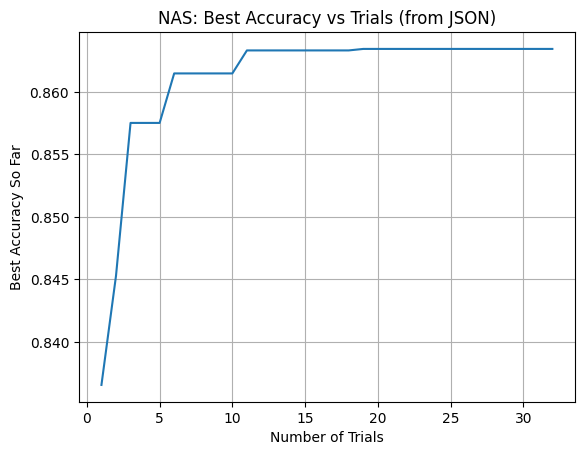

In [27]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load trial log
with open("tut_5_nas_random_trial_log.json") as f:
    trial_log = json.load(f)

# Sort by trial number (important)
trial_log = sorted(trial_log, key=lambda x: x["trial"])

# Extract accuracies
accuracies = [entry["accuracy"] for entry in trial_log]

# Compute best-so-far curve
best_so_far = np.maximum.accumulate(accuracies)

# X axis: number of trials
x = np.arange(1, len(best_so_far) + 1)

# Plot
plt.figure()
plt.plot(x, best_so_far)
plt.xlabel("Number of Trials")
plt.ylabel("Best Accuracy So Far")
plt.title("NAS: Best Accuracy vs Trials (from JSON)")
plt.grid(True)
plt.show()


## Grid Sampler

In [12]:
search_space = {
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choice": ["linear", "identity"],  # single choice shared across layers
}

import torch.nn as nn
from chop.nn.modules import Identity
from transformers import AutoConfig, AutoModelForSequenceClassification
from chop.tools.utils import deepsetattr

def construct_model(trial):
    config = AutoConfig.from_pretrained(checkpoint)

    # Sample ACTUAL values (GridSampler provides these)
    config.num_layers = trial.suggest_categorical("num_layers", [2, 4, 8])
    config.num_heads = trial.suggest_categorical("num_heads", [2, 4, 8, 16])
    config.hidden_size = trial.suggest_categorical("hidden_size", [128, 192, 256, 384, 512])
    config.intermediate_size = trial.suggest_categorical("intermediate_size", [512, 768, 1024, 1536, 2048])

    trial_model = AutoModelForSequenceClassification.from_config(config)

    # One global choice for all eligible layers (keeps grid size manageable + serializable)
    layer_choice = trial.suggest_categorical("linear_layer_choice", ["linear", "identity"])

    if layer_choice == "identity":
        for name, layer in trial_model.named_modules():
            if isinstance(layer, nn.Linear) and layer.in_features == layer.out_features:
                deepsetattr(trial_model, name, Identity())

    return trial_model

from chop.tools import get_trainer

# Global log (lives only in this Python session)
TRIAL_LOG = []  # list of dicts

def objective(trial):

    # Define the model
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    # Save to global variable
    acc = float(eval_results["eval_accuracy"])
    TRIAL_LOG.append({"trial": trial.number, "accuracy": acc})

    # Set the model as an attribute so we can fetch it later
    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]

from optuna.samplers import GridSampler
import optuna

sampler = GridSampler({
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choice": ["linear", "identity"],
})




In [13]:
from optuna.samplers import GridSampler, RandomSampler, TPESampler

sampler = GridSampler(search_space)

import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study-grid",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=30,
    timeout=60 * 60 * 24,
)

import json

with open("tut_5_nas_grid_trial_log.json", "w") as f:
    json.dump(TRIAL_LOG, f, indent=2)

print("Saved trial log to tut_5_nas_grid_trial_log.json")

from pathlib import Path
import dill

model = study.best_trial.user_attrs["model"].cpu()

with open(f"{Path.home()}/tutorial_5_best_grid_model.pkl", "wb") as f:
    dill.dump(model, f)

[I 2026-01-30 19:17:36,308] A new study created in memory with name: bert-tiny-nas-study-grid
/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.663800
1000,0.491400
1500,0.389500
2000,0.356300
2500,0.321200
3000,0.342400


[I 2026-01-30 19:23:08,145] Trial 0 finished with value: 0.86876 and parameters: {'num_layers': 8, 'num_heads': 2, 'hidden_size': 384, 'intermediate_size': 1536, 'linear_layer_choice': 'linear'}. Best is trial 0 with value: 0.86876.
/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.691800
1000,0.544400
1500,0.420900
2000,0.372800
2500,0.339500
3000,0.351800


[I 2026-01-30 19:25:53,489] Trial 1 finished with value: 0.85832 and parameters: {'num_layers': 8, 'num_heads': 2, 'hidden_size': 192, 'intermediate_size': 512, 'linear_layer_choice': 'linear'}. Best is trial 0 with value: 0.86876.
/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


...

Step,Training Loss
500,0.701500
1000,0.698700
1500,0.670500
2000,0.549100
2500,0.492200
3000,0.482600


[I 2026-01-30 21:16:50,845] Trial 28 finished with value: 0.79796 and parameters: {'num_layers': 8, 'num_heads': 2, 'hidden_size': 384, 'intermediate_size': 1536, 'linear_layer_choice': 'identity'}. Best is trial 0 with value: 0.86876.
/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.709800
1000,0.703100
1500,0.683100
2000,0.538500
2500,0.467400
3000,0.447200


[I 2026-01-30 21:23:09,069] Trial 29 finished with value: 0.82264 and parameters: {'num_layers': 2, 'num_heads': 8, 'hidden_size': 512, 'intermediate_size': 2048, 'linear_layer_choice': 'identity'}. Best is trial 0 with value: 0.86876.


Saved trial log to tut_5_nas_grid_trial_log.json


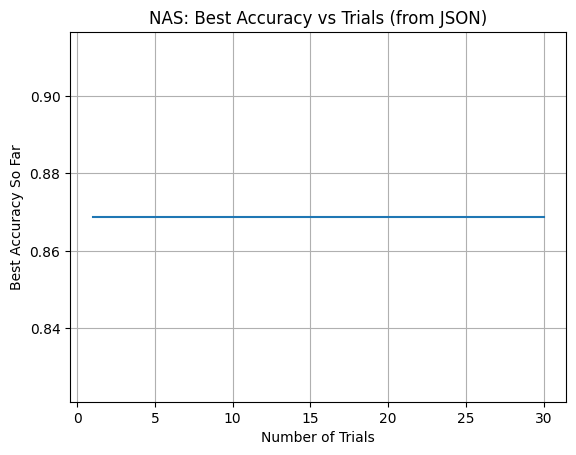

In [14]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load trial log
with open("tut_5_nas_grid_trial_log.json") as f:
    trial_log = json.load(f)

# Sort by trial number (important)
trial_log = sorted(trial_log, key=lambda x: x["trial"])

# Extract accuracies
accuracies = [entry["accuracy"] for entry in trial_log]

# Compute best-so-far curve
best_so_far = np.maximum.accumulate(accuracies)

# X axis: number of trials
x = np.arange(1, len(best_so_far) + 1)

# Plot
plt.figure()
plt.plot(x, best_so_far)
plt.xlabel("Number of Trials")
plt.ylabel("Best Accuracy So Far")
plt.title("NAS: Best Accuracy vs Trials (from JSON)")
plt.grid(True)
plt.show()


## TPE Sampler

In [5]:
from optuna.samplers import GridSampler, RandomSampler, TPESampler

sampler = TPESampler()

import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study-tpe",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=30,
    timeout=60 * 60 * 24,
)

import json

with open("tut_5_nas_tpe_trial_log.json", "w") as f:
    json.dump(TRIAL_LOG, f, indent=2)

print("Saved trial log to tut_5_nas_tpe_trial_log.json")

from pathlib import Path
import dill

model = study.best_trial.user_attrs["model"].cpu()

with open(f"{Path.home()}/tutorial_5_best_tpe_model.pkl", "wb") as f:
    dill.dump(model, f)

[I 2026-01-30 15:12:03,838] A new study created in memory with name: bert-tiny-nas-study-tpe
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'torch.nn.modules.linear.Linear'> which is of type type.
  warnings.warn(message)
/usr/local/lib/python3.11/dist-packages/optuna/distributions.py:515: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.modules.identity.Identity'> which is of type type.
  warnings.warn(message)
/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.669700
1000,0.538500
1500,0.465000
2000,0.443200
2500,0.410300
3000,0.404900


[I 2026-01-30 15:17:44,292] Trial 0 finished with value: 0.83608 and parameters: {'num_layers': 2, 'num_heads': 2, 'hidden_size': 3, 'intermediate_size': 4, 'bert.encoder.layer.0.attention.self.query_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.key_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.0.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.self.query_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.key_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.pooler.dense_type': <class 'chop.nn.modules.identity.Identity'>}. Best is trial 0 with va

Step,Training Loss
500,0.694700
1000,0.645000
1500,0.491600
2000,0.419500
2500,0.384100
3000,0.382100


[I 2026-01-30 15:20:08,294] Trial 1 finished with value: 0.83808 and parameters: {'num_layers': 1, 'num_heads': 0, 'hidden_size': 0, 'intermediate_size': 3, 'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.0.attention.self.key_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.self.query_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.self.key_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.pooler.dense_type': <class 'chop.nn.modules.identity.Identity'>}. Best is trial 1 with value

...

Step,Training Loss
500,0.664800
1000,0.496500
1500,0.404700
2000,0.362900
2500,0.325600
3000,0.349700


[I 2026-01-30 17:29:40,318] Trial 28 finished with value: 0.8664 and parameters: {'num_layers': 1, 'num_heads': 1, 'hidden_size': 3, 'intermediate_size': 3, 'bert.encoder.layer.0.attention.self.query_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.key_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.self.query_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.key_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.pooler.dense_type': <class 'chop.nn.modules.identity.Identity'>}. Best is trial 22 with value: 

Step,Training Loss
500,0.670000
1000,0.521200
1500,0.453700
2000,0.424400
2500,0.404300
3000,0.395300


[I 2026-01-30 17:34:11,953] Trial 29 finished with value: 0.84312 and parameters: {'num_layers': 1, 'num_heads': 2, 'hidden_size': 3, 'intermediate_size': 2, 'bert.encoder.layer.0.attention.self.query_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.key_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.0.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.self.query_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.key_type': <class 'chop.nn.modules.identity.Identity'>, 'bert.encoder.layer.1.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.pooler.dense_type': <class 'chop.nn.modules.identity.Identity'>}. Best is trial 22 with 

Saved trial log to tut_5_nas_tpe_trial_log.json


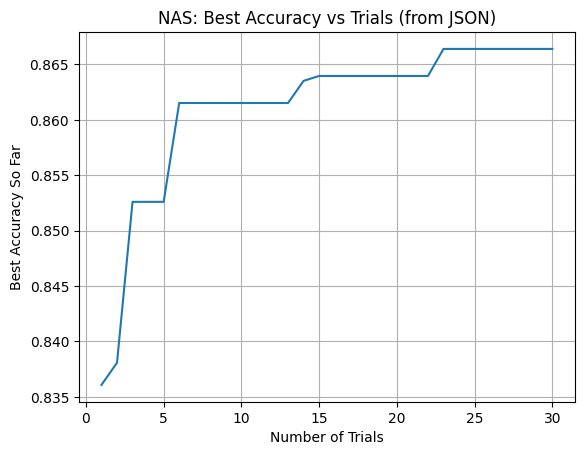

In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load trial log
with open("tut_5_nas_tpe_trial_log.json") as f:
    trial_log = json.load(f)

# Sort by trial number (important)
trial_log = sorted(trial_log, key=lambda x: x["trial"])

# Extract accuracies
accuracies = [entry["accuracy"] for entry in trial_log]

# Compute best-so-far curve
best_so_far = np.maximum.accumulate(accuracies)

# X axis: number of trials
x = np.arange(1, len(best_so_far) + 1)

# Plot
plt.figure()
plt.plot(x, best_so_far)
plt.xlabel("Number of Trials")
plt.ylabel("Best Accuracy So Far")
plt.title("NAS: Best Accuracy vs Trials (from JSON)")
plt.grid(True)
plt.show()


## Task 1 Plot

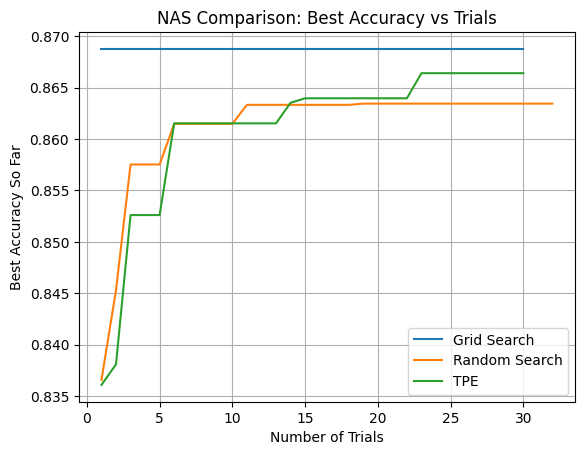

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt


def load_best_so_far(json_path):
    with open(json_path) as f:
        trial_log = json.load(f)

    # Sort by trial number
    trial_log = sorted(trial_log, key=lambda x: x["trial"])

    # Extract accuracies
    accuracies = [entry["accuracy"] for entry in trial_log]

    # Best-so-far curve
    return np.maximum.accumulate(accuracies)


# Load curves
best_grid = load_best_so_far("tut_5_nas_grid_trial_log.json")
best_random = load_best_so_far("tut_5_nas_random_trial_log.json")
best_tpe = load_best_so_far("tut_5_nas_tpe_trial_log.json")

# X axes
x_grid = np.arange(1, len(best_grid) + 1)
x_random = np.arange(1, len(best_random) + 1)
x_tpe = np.arange(1, len(best_tpe) + 1)

# Plot
plt.figure()
plt.plot(x_grid, best_grid, label="Grid Search")
plt.plot(x_random, best_random, label="Random Search")
plt.plot(x_tpe, best_tpe, label="TPE")

plt.xlabel("Number of Trials")
plt.ylabel("Best Accuracy So Far")
plt.title("NAS Comparison: Best Accuracy vs Trials")
plt.legend()
plt.grid(True)
plt.show()


# Task 2

In Tutorial 5, NAS is used to find an optimal configuration of hyperparameters, then we use the CompressionPipeline in Mase to quantize and prune the model after search is finished. However, the final compressed model may not be optimal, since different model architectures may have different sensitivities to quantization and pruning. Ideally, we want to run a compression-aware search flow, where the quantization and pruning is considered in each trial.

a. In the objective function, after the model is constructed and trained for some iterations, call the CompressionPipeline to quantize and prune the model, then continue training for a few more epochs. Use the sampler that yielded the best results in Task 1 to run the compression-aware search. The objective function should return the final accuracy of the model after compression. Consider also the case where final training is performed after quantization/pruning.

b. Plot a new figure that has the number of trials on the x axis, and the maximum achieved accuracy up to that point on the y axis. There should be three curves: 1. the best performance from Task 1 (without compression), compression-aware search without post-compression training, and compression-aware search with post-compression training.

## Compression-aware search without post-compression training

In [2]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


In [6]:
quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

pruning_config = {
    "weight": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
    "activation": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
}

search_space = {
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choice": ["linear", "identity"],
}

In [12]:
import torch.nn as nn
from chop.nn.modules import Identity
from transformers import AutoConfig, AutoModelForSequenceClassification
from chop.tools.utils import deepsetattr
from chop.pipelines import CompressionPipeline
from chop import MaseGraph

class HFInputAdapter(nn.Module):
    def __init__(self, core):
        super().__init__()
        self.core = core

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, labels=None, **kwargs):
        # Most graphified/transformed models typically only need input_ids.
        # If yours also needs attention_mask, pass it positionally.
        out = self.core(input_ids)

        # HF Trainer expects either logits or a dict-like output.
        return out


def construct_model(trial):
    config = AutoConfig.from_pretrained(checkpoint)

    # Sample ACTUAL values (GridSampler provides these)
    config.num_layers = trial.suggest_categorical("num_layers", [2, 4, 8])
    config.num_heads = trial.suggest_categorical("num_heads", [2, 4, 8, 16])
    config.hidden_size = trial.suggest_categorical("hidden_size", [128, 192, 256, 384, 512])
    config.intermediate_size = trial.suggest_categorical("intermediate_size", [512, 768, 1024, 1536, 2048])

    trial_model = AutoModelForSequenceClassification.from_config(config)

    # One global choice for all eligible layers (keeps grid size manageable + serializable)
    layer_choice = trial.suggest_categorical("linear_layer_choice", ["linear", "identity"])

    if layer_choice == "identity":
        for name, layer in trial_model.named_modules():
            if isinstance(layer, nn.Linear) and layer.in_features == layer.out_features:
                deepsetattr(trial_model, name, Identity())

    return trial_model

from chop.tools import get_trainer

# Global log (lives only in this Python session)
TRIAL_LOG = []  # list of dicts

def objective(trial):

    # =================================
    # Step 1. Train the original model
    # =================================
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()

    # =================================
    # Step 2. Evaluate the compressed model (without post-compression training)
    # =================================
    model = model.cpu()
    mg = MaseGraph(model)
    pipe = CompressionPipeline()

    mg, _ = pipe(
        mg,
        pass_args={
            "quantize_transform_pass": quantization_config,
            "prune_transform_pass": pruning_config,
        },
    )

    compressed_model = HFInputAdapter(mg.model)

    trainer2 = get_trainer(
    model=compressed_model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
    num_train_epochs=1,
    )
    
    eval_results = trainer2.evaluate()

    # Save to global variable
    acc = float(eval_results["eval_accuracy"])
    TRIAL_LOG.append({"trial": trial.number, "accuracy": acc})

    # Set the model as an attribute so we can fetch it later
    trial.set_user_attr("model", compressed_model)

    return eval_results["eval_accuracy"]


In [13]:
from optuna.samplers import GridSampler

sampler = GridSampler({
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choice": ["linear", "identity"],
})

sampler = GridSampler(search_space)

import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study-grid",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=30,
    timeout=60 * 60 * 24,
)

import json

with open("tut_5_nas_grid_trial_log_task_2_1.json", "w") as f:
    json.dump(TRIAL_LOG, f, indent=2)

print("Saved trial log to tut_5_nas_grid_trial_log_task_2_1.json")

from pathlib import Path
import dill

model = study.best_trial.user_attrs["model"].cpu()

with open(f"{Path.home()}/tutorial_5_best_grid_model_task_2_1.pkl", "wb") as f:
    dill.dump(model, f)

[I 2026-02-01 16:26:55,912] A new study created in memory with name: bert-tiny-nas-study-grid
/workspace/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.664300
1000,0.492300
1500,0.407900
2000,0.369900
2500,0.327900
3000,0.345300


`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
INFO     Getting dummy input for prajjwal1/bert-tiny.
[W 2026-02-01 16:31:23,399] Trial 0 failed with parameters: {'num_layers': 8, 'num_heads': 2, 'hidden_size': 384, 'intermediate_size': 1536, 'linear_layer_choice': 'linear'} because of the following error: KeyError('by').
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_684/3981325326.py", line 72, in objective
    mg, _ = pipe(
            ^^^^^
  File "/workspace/mase/src/chop/pipelines/auto_pipeline.py", line 72, in __call__
    mg, pass_outputs = self._run_pass_group(
                       ^^^^^^^^^^^^^^^^^^^^^
  File "/workspace/mase/src/chop/pipelines/auto_pipeline.py", line 53, in _run_pass_group
    mg, pass_output = pass_fn

tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
tensor([[[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]],


        [[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]]])
tensor([[[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
   

KeyError: 'by'

## Compression-aware search with post-compression training

In [ ]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

In [ ]:
quantization_config = {
    "by": "type",
    "default": {
        "config": {
            "name": None,
        }
    },
    "linear": {
        "config": {
            "name": "integer",
            # data
            "data_in_width": 8,
            "data_in_frac_width": 4,
            # weight
            "weight_width": 8,
            "weight_frac_width": 4,
            # bias
            "bias_width": 8,
            "bias_frac_width": 4,
        }
    },
}

pruning_config = {
    "weight": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
    "activation": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
}

search_space = {
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choice": ["linear", "identity"],
}

In [ ]:
import torch.nn as nn
from chop.nn.modules import Identity
from transformers import AutoConfig, AutoModelForSequenceClassification
from chop.tools.utils import deepsetattr
from chop.pipelines import CompressionPipeline
from chop import MaseGraph

def construct_model(trial):
    config = AutoConfig.from_pretrained(checkpoint)

    # Sample ACTUAL values (GridSampler provides these)
    config.num_layers = trial.suggest_categorical("num_layers", [2, 4, 8])
    config.num_heads = trial.suggest_categorical("num_heads", [2, 4, 8, 16])
    config.hidden_size = trial.suggest_categorical("hidden_size", [128, 192, 256, 384, 512])
    config.intermediate_size = trial.suggest_categorical("intermediate_size", [512, 768, 1024, 1536, 2048])

    trial_model = AutoModelForSequenceClassification.from_config(config)

    # One global choice for all eligible layers (keeps grid size manageable + serializable)
    layer_choice = trial.suggest_categorical("linear_layer_choice", ["linear", "identity"])

    if layer_choice == "identity":
        for name, layer in trial_model.named_modules():
            if isinstance(layer, nn.Linear) and layer.in_features == layer.out_features:
                deepsetattr(trial_model, name, Identity())

    return trial_model

from chop.tools import get_trainer

# Global log (lives only in this Python session)
TRIAL_LOG = []  # list of dicts

def objective(trial):

    # =================================
    # Step 1. Train the original model
    # =================================
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1,
    )

    trainer.train()

    # =================================
    # Step 2. Train and evaluate the compressed model (with post-compression training)
    # =================================
    mg = MaseGraph(model)
    pipe = CompressionPipeline()

    mg, _ = pipe(
        mg,
        pass_args={
            "quantize_transform_pass": quantization_config,
            "prune_transform_pass": pruning_config,
        },
    )

    trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
    num_train_epochs=1,
    )

    trainer.train()
    
    eval_results = trainer.evaluate()

    # Save to global variable
    acc = float(eval_results["eval_accuracy"])
    TRIAL_LOG.append({"trial": trial.number, "accuracy": acc})

    # Set the model as an attribute so we can fetch it later
    trial.set_user_attr("model", mg.model)

    return eval_results["eval_accuracy"]


In [ ]:
from optuna.samplers import GridSampler

sampler = GridSampler({
    "num_layers": [2, 4, 8],
    "num_heads": [2, 4, 8, 16],
    "hidden_size": [128, 192, 256, 384, 512],
    "intermediate_size": [512, 768, 1024, 1536, 2048],
    "linear_layer_choice": ["linear", "identity"],
})

sampler = GridSampler(search_space)

import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study-grid",
    sampler=sampler,
)

study.optimize(
    objective,
    n_trials=30,
    timeout=60 * 60 * 24,
)

import json

with open("tut_5_nas_grid_trial_log_task_2_2.json", "w") as f:
    json.dump(TRIAL_LOG, f, indent=2)

print("Saved trial log to tut_5_nas_grid_trial_log_task_2_2.json")

from pathlib import Path
import dill

model = study.best_trial.user_attrs["model"].cpu()

with open(f"{Path.home()}/tutorial_5_best_grid_model_task_2_2.pkl", "wb") as f:
    dill.dump(model, f)